# Unconstrained Optimization with GMM

Finding minima and maxima by conditioning on derivatives being zero.

We include derivatives in our training data and condition on them being zero to find stationary points.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings

# Configure JAX to use CPU (avoids GPU/XLA compatibility issues)
import os
os.environ['JAX_PLATFORMS'] = 'cpu'

# Import reusable utilities from local module
from generative_optimization import (
    generate_samples,
    estimate_sample_size,
    best_gmm,
    best_gmm_bic,
    cluster_stats,
    validate_gmm
)

# Figure settings
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['figure.dpi'] = 150

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore', category=RuntimeWarning)

---
<a id='optimization'></a>
## 3. Optimization with Generative Models

To find minima/maxima, we include derivatives in our data and condition on them being zero.

In [ ]:
# Using the same polynomial: y = x^4 - 4x^2 + x + 3
# Derivative: y' = 4x^3 - 8x + 1

x = np.linspace(-2.25, 2, 200)
y = x**4 - 4*x**2 + x + 3
y_prime = 4*x**3 - 8*x + 1

# Find stationary points analytically
stationary_pts = np.roots([4, 0, -8, 1])
print("Stationary points (where y'=0):")
print(stationary_pts)

Stationary points (where y'=0):
[-1.4729976   1.34699741  0.12600019]


In [ ]:
# Build GMM with x, y, and y'
data = np.array([x, y, y_prime]).T

gmm, info = best_gmm(data, verbose=False)
print(f"Best model: {info['best_k']} components")

Best model: 13 components


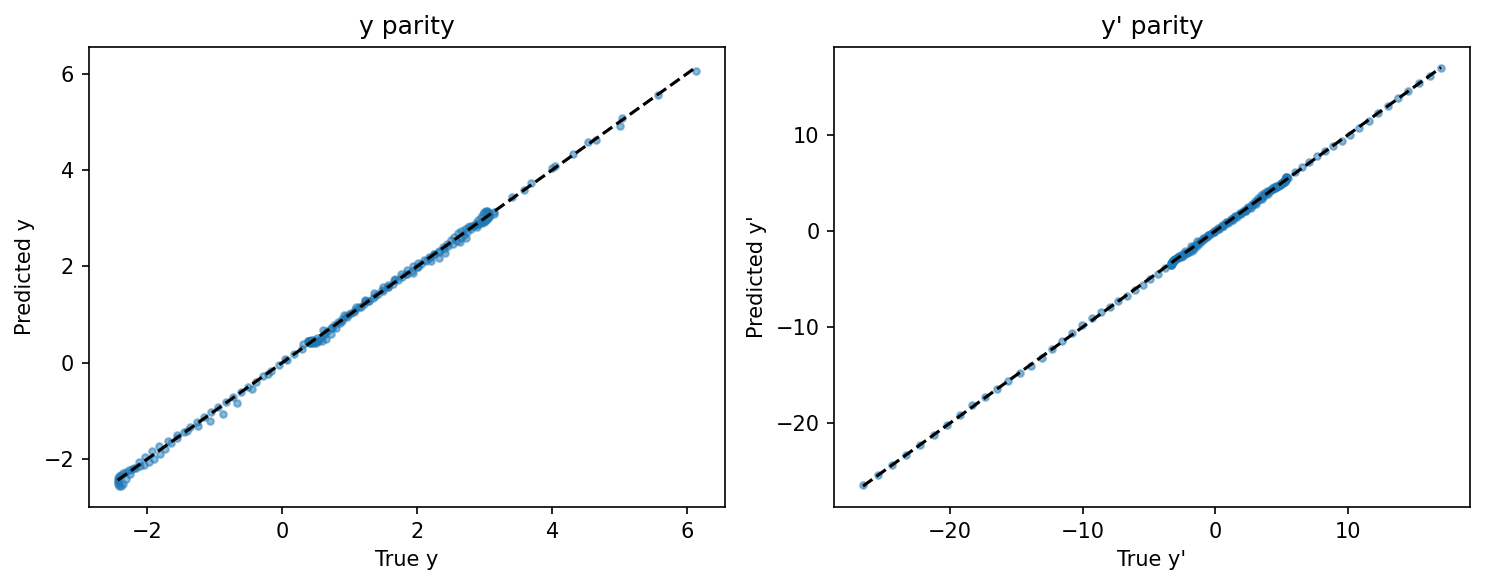

In [ ]:
# Validate: condition on x, predict y and y'
pred = gmm.predict([0], data[:, 0:1])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(data[:, 1], pred[:, 0], alpha=0.5, s=10)
axes[0].plot([data[:, 1].min(), data[:, 1].max()], 
             [data[:, 1].min(), data[:, 1].max()], 'k--')
axes[0].set_xlabel('True y')
axes[0].set_ylabel('Predicted y')
axes[0].set_title('y parity')

axes[1].scatter(data[:, 2], pred[:, 1], alpha=0.5, s=10)
axes[1].plot([data[:, 2].min(), data[:, 2].max()], 
             [data[:, 2].min(), data[:, 2].max()], 'k--')
axes[1].set_xlabel("True y'")
axes[1].set_ylabel("Predicted y'")
axes[1].set_title("y' parity")

plt.tight_layout()
plt.show()

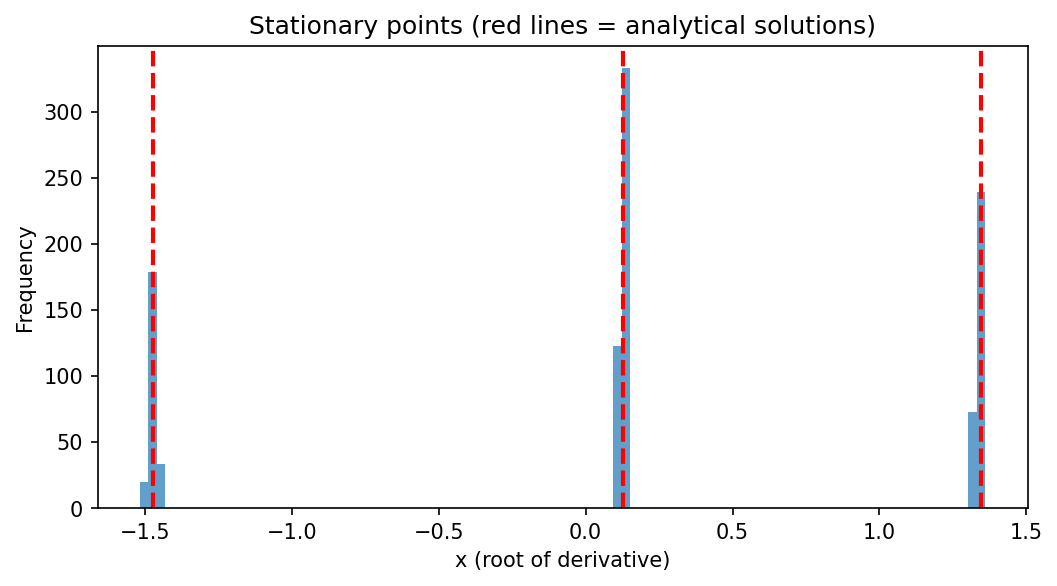

In [ ]:
# Find stationary points by conditioning on y'=0
c = gmm.condition([2], [[0.0]])

results = c.sample(1000)

plt.figure(figsize=(8, 4))
plt.hist(results[:, 0], bins=100, alpha=0.7)
plt.xlabel('x (root of derivative)')
plt.ylabel('Frequency')

for r in np.roots([4, 0, -8, 1]):
    plt.axvline(r, c='r', ls='--', lw=2)

plt.title("Stationary points (red lines = analytical solutions)")
plt.show()

In [ ]:
# Distinguish minima from maxima using second derivative
# y'' = 12x^2 - 8
# Use sign: +1 if y'' > 0 (minimum), -1 if y'' < 0 (maximum)

y_double_prime_sign = np.where((12 * x**2 - 8) > 0, 1, -1).astype(int)

data = np.array([x, y, y_prime, y_double_prime_sign]).T

gmm, info = best_gmm(data, verbose=False)
print(f"Best model: {info['best_k']} components")

Best model: 10 components


Maximum (y'=0, y''<0):
  0:   0.1268 +/- 0.0149 (n=100)


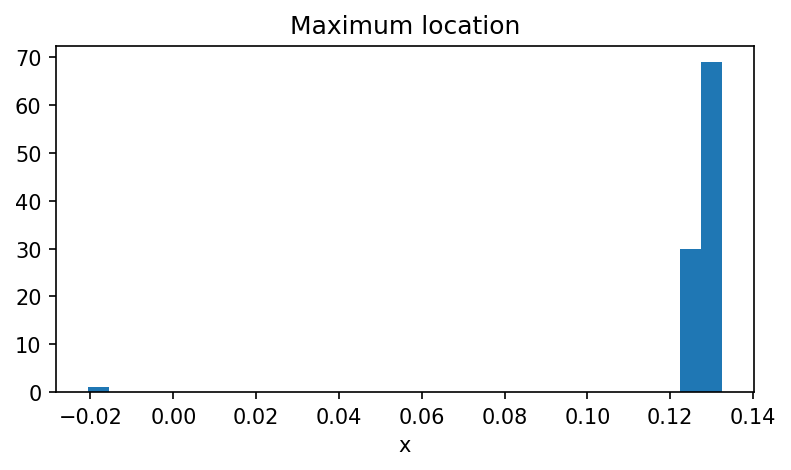

In [ ]:
# Find maximum: condition on y'=0 AND y''<0 (sign=-1)
c = gmm.condition([2, 3], [[0.0, -1]])

results = c.sample(100)
print("Maximum (y'=0, y''<0):")
cluster_stats(results[:, 0])

plt.figure(figsize=(6, 3))
plt.hist(results[:, 0], bins=30)
plt.xlabel('x')
plt.title('Maximum location')
plt.show()

Minima (y'=0, y''>0):
  0:  -1.4578 +/- 0.0135 (n=60)
  1:   1.3423 +/- 0.0226 (n=40)


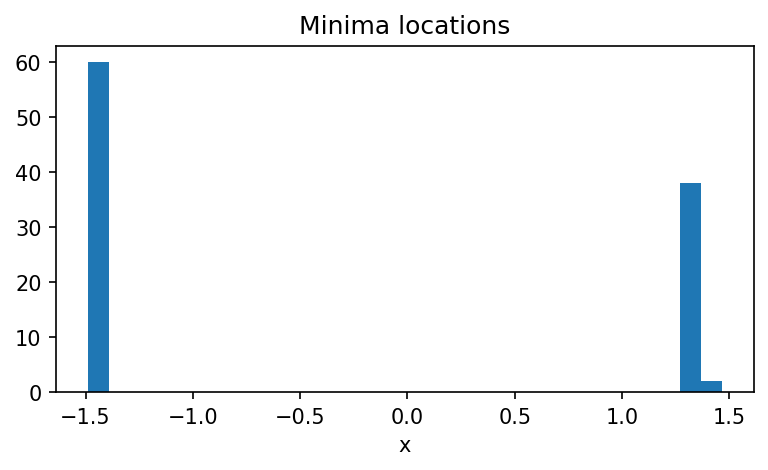

In [ ]:
# Find minima: condition on y'=0 AND y''>0 (sign=+1)
c = gmm.condition([2, 3], [[0.0, 1]])

results = c.sample(100)
print("Minima (y'=0, y''>0):")
cluster_stats(results[:, 0])

plt.figure(figsize=(6, 3))
plt.hist(results[:, 0], bins=30)
plt.xlabel('x')
plt.title('Minima locations')
plt.show()